In [3]:
import requests
from io import BytesIO


# Standard Library (Python)
import os
import re
import json
import time
import random
import string
import warnings
from typing import Any

warnings.filterwarnings('ignore')


# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP / Text Processing
import emoji
from datasets import load_dataset

# Scikit-learn (ML)
from sklearn.model_selection import train_test_split
from sklearn.base import clone

# Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
    classification_report
)

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Model Persistence
import joblib

In [4]:
def load_language_dictionary(file_path: str, lang_label: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df['lang'] = lang_label
    return df


LANGUAGE_FILES = {
    'arabizi' : '../data/language_dictionaries/arabizi.csv',
    'french'  : '../data/language_dictionaries/french.csv',
    'english' : '../data/language_dictionaries/english.csv',
    'darija'  : '../data/language_dictionaries/darija.csv',
    'msa'     : '../data/language_dictionaries/msa.csv',
}

df = (
    pd.concat(
        [load_language_dictionary(path, lang) for lang, path in LANGUAGE_FILES.items()],
        ignore_index=True
    )
    .sample(frac=1)
    .reset_index(drop=True)
)

print(f"Total rows  : {len(df)}")
print(f"Languages   : {df['lang'].value_counts().to_dict()}")

Total rows  : 72656
Languages   : {'darija': 20008, 'msa': 20008, 'arabizi': 19008, 'french': 7518, 'english': 6114}


In [5]:
df.head()

,text,lang
0,على حساب واحد لاستطلاع داخلي دارتو دي إي مع خب...,darija
1,ثقافة دْيَال حْشِيشْةْ دِيَال مْرِيكَان. مْعَ ...,darija
2,"Inscrite depuis plusieurs mois, cette salle es...",french
3,لست اظن انني ساتصل بك ثانية,msa
4,Was rated high for onion soup but no onions in...,english


In [6]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72656 entries, 0 to 72655
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    72649 non-null  str  
 1   lang    72656 non-null  str  
dtypes: str(2)
memory usage: 15.8 MB


In [8]:
#Check for Duplicate Values
duplicate_count = df.duplicated().sum()

if (duplicate_count>0):
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected in the data.")

Before: 72656
121 Duplicate values found in the data.
After: 72535


In [7]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

text    7
dtype: int64


In [8]:
df = df.dropna()

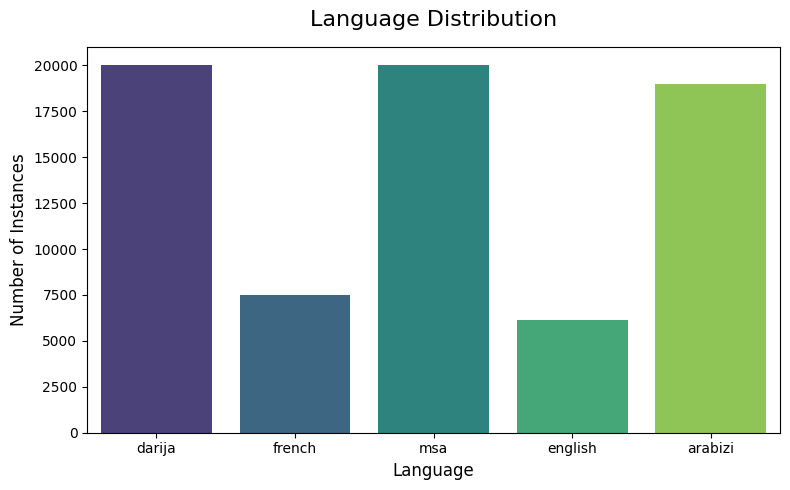

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='lang', hue='lang', palette='viridis', legend=False)
plt.title(f'Language Distribution', fontsize=16, pad=15)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
TARGET = 12000

ds_fr = load_dataset("tblard/allocine", split="train", trust_remote_code=False)

df_fr = (
    pd.DataFrame(ds_fr)[['review']]
    .rename(columns={'review': 'text'})
    .dropna()
    .sample(TARGET, random_state=42)
    .assign(lang='french')
)

TARGET = 13000

ds_en = load_dataset("stanfordnlp/imdb", split="train")

df_en = (
    pd.DataFrame(ds_en)[['text']]
    .dropna()
    .sample(TARGET, random_state=42)
    .assign(lang='english')
)

In [11]:
print(f"French sentences: {len(df_fr)}")
print(f"English sentences: {len(df_en)}")

French sentences: 12000
English sentences: 13000


In [12]:
df = pd.concat([df, df_fr, df_en], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

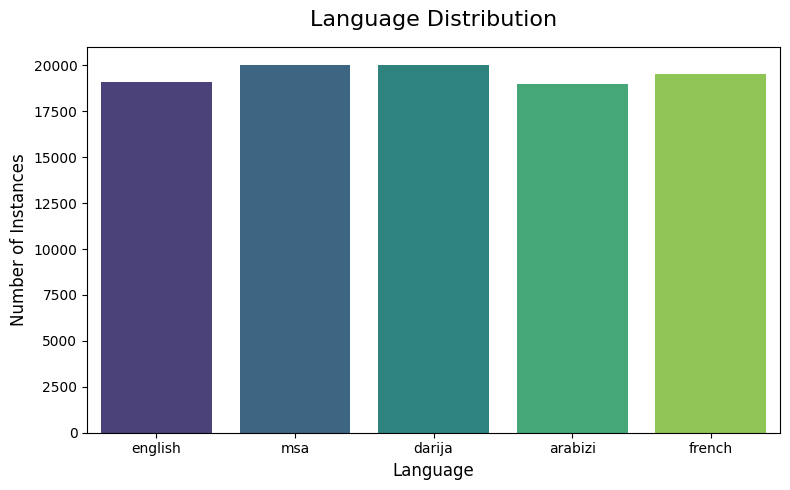

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='lang', hue='lang', palette='viridis', legend=False)
plt.title(f'Language Distribution', fontsize=16, pad=15)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
def text_cleanning(text: str) -> str:
    text = str(text).lower()

    # 1. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 2. Remove phone numbers
    text = re.sub(r'\b\+?\d[\d\s\-\(\)]{7,}\d\b', ' ', text)

    # 3. Remove emojis
    text = emoji.replace_emoji(text, replace=' ')

    # 4. Replace punctuation with spaces
    text = text.translate(
        str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    )

    # 5. Clean tokens
    tokens = text.split()
    cleaned_tokens = []
    for token in tokens:
        # Garder seulement les caractères valides
        token = re.sub(r'[^a-z\u00C0-\u017E\u0600-\u06FF0-9]', '', token)

        if not token:
            continue

        # ← NOUVEAU : supprimer les tokens purement numériques (ex: 320, 40, 5)
        # Garder uniquement si le token contient au moins une lettre
        has_letter = re.search(r'[a-z\u00C0-\u017E\u0600-\u06FF]', token)
        if has_letter:
            cleaned_tokens.append(token)

    text = ' '.join(cleaned_tokens)

    # 6. Normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. Collapse spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

test_cases = [
    "Ce restaurant est vraiment mzyan  325 😍, je recommande !",
    "Appelez le +212 6 12 34 56 78 pour réserver",
    "Visitez https://www.restaurant.ma pour plus d'infos",
    "3ayyan had lmakan bzzaf !! w la service zwina",
    "J'apprécie la qualité... mais y'a aucun respect!!!",
    "La tacos zin 3/5 w b9a tsna 40min",
    "ىوىثثوببيبا",
]

for t in test_cases:
    print(f"BEFORE : {t}")
    print(f"AFTER  : {text_cleanning(t)}\n")

BEFORE : Ce restaurant est vraiment mzyan  325 😍, je recommande !
AFTER  : ce restaurant est vraiment mzyan je recommande

BEFORE : Appelez le +212 6 12 34 56 78 pour réserver
AFTER  : appelez le pour réserver

BEFORE : Visitez https://www.restaurant.ma pour plus d'infos
AFTER  : visitez pour plus d infos

BEFORE : 3ayyan had lmakan bzzaf !! w la service zwina
AFTER  : 3ayyan had lmakan bzzaf w la service zwina

BEFORE : J'apprécie la qualité... mais y'a aucun respect!!!
AFTER  : j apprécie la qualité mais y a aucun respect

BEFORE : La tacos zin 3/5 w b9a tsna 40min
AFTER  : la tacos zin w b9a tsna 40min

BEFORE : ىوىثثوببيبا
AFTER  : ىوىثثوببيبا



In [15]:
df['text'] = df['text'].apply(text_cleanning)

In [16]:
def split_data(
    df: pd.DataFrame,
    text_col: str,
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
    stratify: str | None = "auto",
    verbose: bool = True,
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:

    strat = df[target_col] if stratify == "auto" else stratify
 
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col],
        df[target_col],
        test_size=test_size,
        random_state=random_state,
        stratify=strat,
    )
 
    if verbose:
        print(f"Train : {len(X_train):,} samples")
        print(f"Test  : {len(X_test):,} samples")
 
    return X_train, X_test, y_train, y_test

In [54]:
X_train, X_test, y_train, y_test = split_data(
    df,
    text_col='text',
    target_col='lang',
    verbose=True
    )

Train : 78,025 samples
Test  : 19,507 samples


In [17]:
VectorizedData = dict[str, dict[str, Any]]

vectorizers = {
    'BoW'    : CountVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=5000),
    'TF-IDF' : TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=5000, sublinear_tf=True),
}

def precompute_vectorizations(
    vectorizers: dict[str, Any],
    X_train: pd.Series,
    X_test: pd.Series,
    verbose: bool = True,
) -> VectorizedData:

    vectorized_data: VectorizedData = {}
 
    for vec_name, vectorizer in vectorizers.items():
        if verbose:
            print(f"Fitting {vec_name}...")
 
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec  = vectorizer.transform(X_test)
 
        vectorized_data[vec_name] = {
            "X_train"   : X_train_vec,
            "X_test"    : X_test_vec,
            "vectorizer": vectorizer,
        }
 
        if verbose:
            print(f"  → shape : {X_train_vec.shape}")
 
    return vectorized_data



In [ ]:
vectorized_data = precompute_vectorizations(vectorizers, X_train, X_test)

Fitting BoW...
  → shape : (78025, 5000)
Fitting TF-IDF...
  → shape : (78025, 5000)


In [27]:
TrainedModels  = dict[tuple[str, str], Any] 

classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                 : LinearSVC(max_iter=2000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

def evaluate_models(
    vectorized_data: VectorizedData,
    classifiers: dict[str, Any],
    y_train: pd.Series,
    y_test: pd.Series,
    verbose: bool = True,
) -> tuple[pd.DataFrame, TrainedModels]:

    records: list[dict] = []
    trained_models: TrainedModels = {}
 
    for vec_name, data in vectorized_data.items():
        X_tr = data["X_train"]
        X_te = data["X_test"]
 
        for clf_name, clf in classifiers.items():
            model = clone(clf)
 
            start = time.time()
            model.fit(X_tr, y_train)
            train_time = time.time() - start
 
            y_pred = model.predict(X_te)
            f1     = f1_score(y_test, y_pred, average="weighted")
            acc    = accuracy_score(y_test, y_pred)
 
            records.append({
                "Vectorizer": vec_name,
                "Model"     : clf_name,
                "Accuracy"  : round(float(acc), 4),
                "F1"        : round(float(f1), 4),
                "Train Time": round(float(train_time), 3),
            })
 
            trained_models[(vec_name, clf_name)] = model
 
            if verbose:
                print(
                    f"[{vec_name:<7}] {clf_name:<22} "
                    f"| F1={f1:.4f} | Acc={acc:.4f} | {train_time:.2f}s"
                )
 
    results_df = (
        pd.DataFrame(records)
        .sort_values("F1", ascending=False)
        .reset_index(drop=True)
    )
 
    return results_df, trained_models

In [28]:
results_df, trained_models = evaluate_models(vectorized_data, classifiers, y_train, y_test)

[BoW    ] Logistic Regression    | F1=0.9808 | Acc=0.9808 | 86.60s
[BoW    ] SVM                    | F1=0.9811 | Acc=0.9811 | 94.21s
[BoW    ] Random Forest          | F1=0.9790 | Acc=0.9790 | 48.30s
[TF-IDF ] Logistic Regression    | F1=0.9833 | Acc=0.9833 | 8.06s
[TF-IDF ] SVM                    | F1=0.9845 | Acc=0.9845 | 5.70s
[TF-IDF ] Random Forest          | F1=0.9793 | Acc=0.9793 | 45.24s


In [29]:
print("\nEvaluation Results:")
print(results_df.to_string(index=False))


Evaluation Results:
Vectorizer               Model  Accuracy     F1  Train Time
    TF-IDF                 SVM    0.9845 0.9845       5.701
    TF-IDF Logistic Regression    0.9833 0.9833       8.058
       BoW                 SVM    0.9811 0.9811      94.207
       BoW Logistic Regression    0.9808 0.9808      86.601
    TF-IDF       Random Forest    0.9793 0.9793      45.236
       BoW       Random Forest    0.9790 0.9790      48.303


In [30]:
def plot_top_confusion_matrices(
    results_df: pd.DataFrame,
    trained_models: TrainedModels,
    vectorized_data: VectorizedData,
    y_test: pd.Series,
    top_n: int = 2,
) -> None:

    top_models = results_df.head(top_n)
 
    fig, axes = plt.subplots(1, top_n, figsize=(9 * top_n, 7))
    if top_n == 1:
        axes = [axes]
 
    for rank, (ax, (_, row)) in enumerate(zip(axes, top_models.iterrows()), start=1):
        vec_name = row["Vectorizer"]
        clf_name = row["Model"]
 
        key = (vec_name, clf_name)
        if key not in trained_models:
            raise KeyError(
                f"Model '{clf_name}' + Vectorizer '{vec_name}' "
                f"Not found in trained_models."
            )
 
        model  = trained_models[key]
        X_test = vectorized_data[vec_name]["X_test"]
        y_pred = model.predict(X_test)
 
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            cmap    ="Blues",
            ax      = ax,
            colorbar= True,
        )
        ax.set_title(
            f"#{rank} — {vec_name} + {clf_name}\n"
            f"F1={row['F1']:.4f} | Acc={row['Accuracy']:.4f}",
            fontsize=13,
        )
 
    plt.suptitle(
        f" Confusion Matrix — Top {top_n} Models",
        fontsize=15, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()


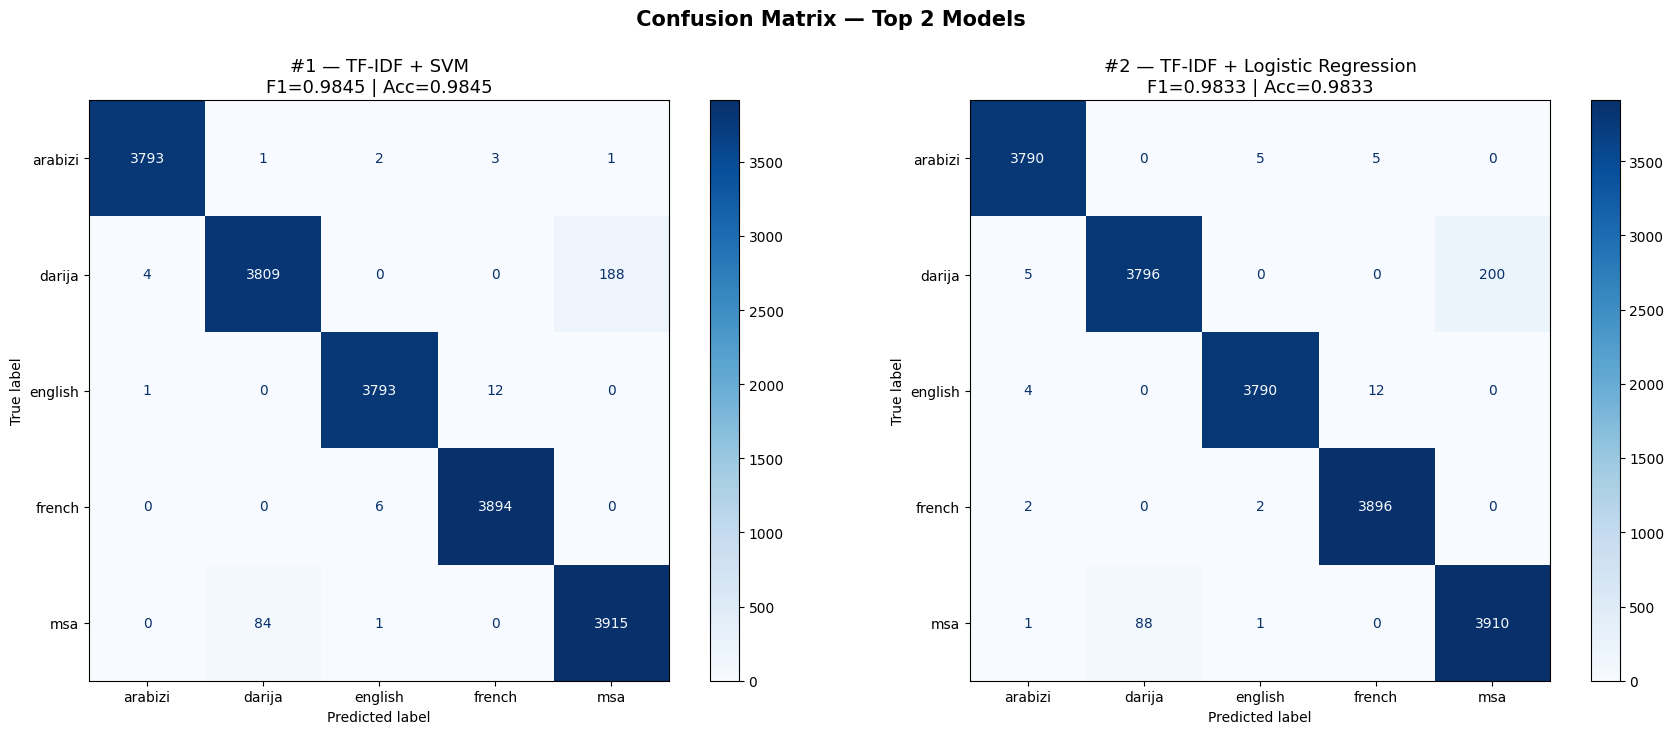

In [31]:
plot_top_confusion_matrices(results_df, trained_models, vectorized_data, y_test, top_n=2)

In [32]:
def save_best_model(
    results_df: pd.DataFrame,
    trained_models: TrainedModels,
    vectorized_data: VectorizedData,
    save_path: str,
) -> dict[str, Any]:

    best_row = results_df.iloc[0]
    best_vec = best_row["Vectorizer"]
    best_clf = best_row["Model"]
 
    key = (best_vec, best_clf)
    if key not in trained_models:
        raise KeyError(
            f"Model '{best_clf}' + Vectorizer '{best_vec}' "
            f"Not found in trained_models."
        )
 
    bundle = {
        "model"     : trained_models[key],
        "vectorizer": vectorized_data[best_vec]["vectorizer"],
        "vec_name"  : best_vec,
        "clf_name"  : best_clf,
        "f1"        : best_row["F1"],
        "accuracy"  : best_row["Accuracy"],
    }
 
    os.makedirs(save_path, exist_ok=True)
    joblib.dump(bundle["model"],       f"{save_path}/model.pkl")
    joblib.dump(bundle["vectorizer"],  f"{save_path}/vectorizer.pkl")
 
    meta = {k: v for k, v in bundle.items() if k not in ("model", "vectorizer")}

    with open(f"{save_path}/meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
 
    return bundle


In [33]:
best_model_bundle = save_best_model(results_df, trained_models, vectorized_data, save_path="../models/language_identification_without_code_switching")

In [18]:
classes   = sorted(df['lang'].unique())
class2idx = {c: i for i, c in enumerate(classes)}

def create_hard_label(label: str, class2idx: dict) -> np.ndarray:

    vec = np.zeros(len(class2idx), dtype=np.float32)

    if label in class2idx:
        vec[class2idx[label]] = 1.0
        
    return vec

In [19]:
df["label"] = df.apply(
    lambda row: create_hard_label(row['lang'], class2idx), axis=1
)

In [20]:
def apply_token_level_textmix(
    text1  : str,
    text2  : str,
    alpha  : float = 0.4
) -> str:
    words1 = str(text1).split()
    words2 = str(text2).split()

    if not words1 or not words2:
        return text1 if words1 else text2

    lam    = np.random.beta(alpha, alpha)

    # Cut proportional to lambda
    n1     = max(1, int(len(words1) * lam))
    n2     = max(1, int(len(words2) * (1 - lam)))

    cut1   = words1[:n1]
    cut2   = words2[:n2]

    mixed  = cut1 + cut2
    random.shuffle(mixed)

    return ' '.join(mixed)


def generate_union_labeled_dataset(
    df           : pd.DataFrame,
    lang_col     : str   = 'lang',
    text_col     : str   = 'text',
    n_samples    : int   = 20_000,
    alpha        : float = 0.4,
    random_state : int   = 42
) -> tuple:
    random.seed(random_state)
    np.random.seed(random_state)

    classes    = sorted(df[lang_col].unique())
    class2idx  = {c: i for i, c in enumerate(classes)}
    n_classes  = len(classes)

    lang_pairs = [
            ('french', 'arabizi'),
            ('french', 'darija_arab'),
            ('french', 'msa'),
            
            ('english', 'arabizi'),
            ('english', 'darija_arab'),
            ('english', 'msa'),
            
            ('french', 'english'),
            
            ('msa', 'darija_arab'),
            ('arabizi', 'darija_arab'),
            ('arabizi', 'msa')
        ]

    texts       = []
    hard_labels = []

    n_per_pair  = n_samples // len(lang_pairs)

    for lang1, lang2 in lang_pairs:
        pool1 = df[df[lang_col] == lang1][text_col].dropna().tolist()
        pool2 = df[df[lang_col] == lang2][text_col].dropna().tolist()

        if not pool1 or not pool2:
            continue

        for _ in range(n_per_pair):
            t1  = random.choice(pool1)
            t2  = random.choice(pool2)

            mixed_text = apply_token_level_textmix(t1, t2, alpha)

            label = np.zeros(n_classes, dtype=np.float32)
            label[class2idx[lang1]] = 1.0
            label[class2idx[lang2]] = 1.0

            texts.append(mixed_text)
            hard_labels.append(label)

    return texts, hard_labels

In [59]:
X_train_raw, X_test_raw, y_train, y_test = split_data(
    df,
    text_col   ="text",
    target_col ="lang",
    stratify   ="auto",
    verbose    = True,
)

Train : 78,025 samples
Test  : 19,507 samples


In [60]:
df_train = df.loc[X_train_raw.index].copy()
df_test  = df.loc[X_test_raw.index].copy()

In [61]:
texts_mix_train, labels_mix_train = generate_union_labeled_dataset(
    df_train,
    n_samples=20_000,
    random_state=42,
)

texts_mix_test, labels_mix_test = generate_union_labeled_dataset(
    df_test,
    n_samples=4_000,
    random_state=99,
)

In [62]:
df_mixed_train = pd.DataFrame({
    'text' : texts_mix_train,
    'lang' : 'mixed',
    'label': labels_mix_train,
})

df_train_augmented = (
    pd.concat([df_train, df_mixed_train], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Train distribution after augmentation:")
print(df_train_augmented['lang'].value_counts())

Train distribution after augmentation:
lang
darija     16003
msa        15998
french     15599
english    15225
arabizi    15200
mixed      12000
Name: count, dtype: int64


In [63]:
df_mixed_test = pd.DataFrame({
    'text' : texts_mix_test,
    'lang' : 'mixed',
    'label': labels_mix_test,
})

df_test_augmented = (
    pd.concat([df_test, df_mixed_test], ignore_index=True)
    .sample(frac=1, random_state=99)
    .reset_index(drop=True)
)

print("\nTest distribution after augmentation:")
print(df_test_augmented['lang'].value_counts())


Test distribution after augmentation:
lang
darija     4001
msa        4000
french     3900
english    3806
arabizi    3800
mixed      2400
Name: count, dtype: int64


In [65]:
X_train = df_train_augmented['text']
X_test  = df_test_augmented['text']
y_train = df_train_augmented['lang']
y_test  = df_test_augmented['lang']

In [66]:
vectorized_data = precompute_vectorizations(
    vectorizers,
    X_train,
    X_test,
)

Fitting BoW...
  → shape : (90025, 5000)
Fitting TF-IDF...
  → shape : (90025, 5000)


In [31]:
results_df, trained_models = evaluate_models(vectorized_data, classifiers, y_train, y_test)

[BoW    ] Logistic Regression    | F1=0.9281 | Acc=0.9292 | 277.11s
[BoW    ] SVM                    | F1=0.9276 | Acc=0.9293 | 1154.25s
[BoW    ] Random Forest          | F1=0.9271 | Acc=0.9318 | 131.61s
[TF-IDF ] Logistic Regression    | F1=0.9076 | Acc=0.9191 | 31.19s
[TF-IDF ] SVM                    | F1=0.9065 | Acc=0.9187 | 25.51s
[TF-IDF ] Random Forest          | F1=0.9314 | Acc=0.9351 | 134.63s


In [32]:
print("\nEvaluation Results After Augmentation:")
print(results_df.to_string(index=False))


Evaluation Results After Augmentation:
Vectorizer               Model  Accuracy     F1  Train Time
    TF-IDF       Random Forest    0.9351 0.9314     134.629
       BoW Logistic Regression    0.9292 0.9281     277.113
       BoW                 SVM    0.9293 0.9276    1154.253
       BoW       Random Forest    0.9318 0.9271     131.606
    TF-IDF Logistic Regression    0.9191 0.9076      31.188
    TF-IDF                 SVM    0.9187 0.9065      25.512


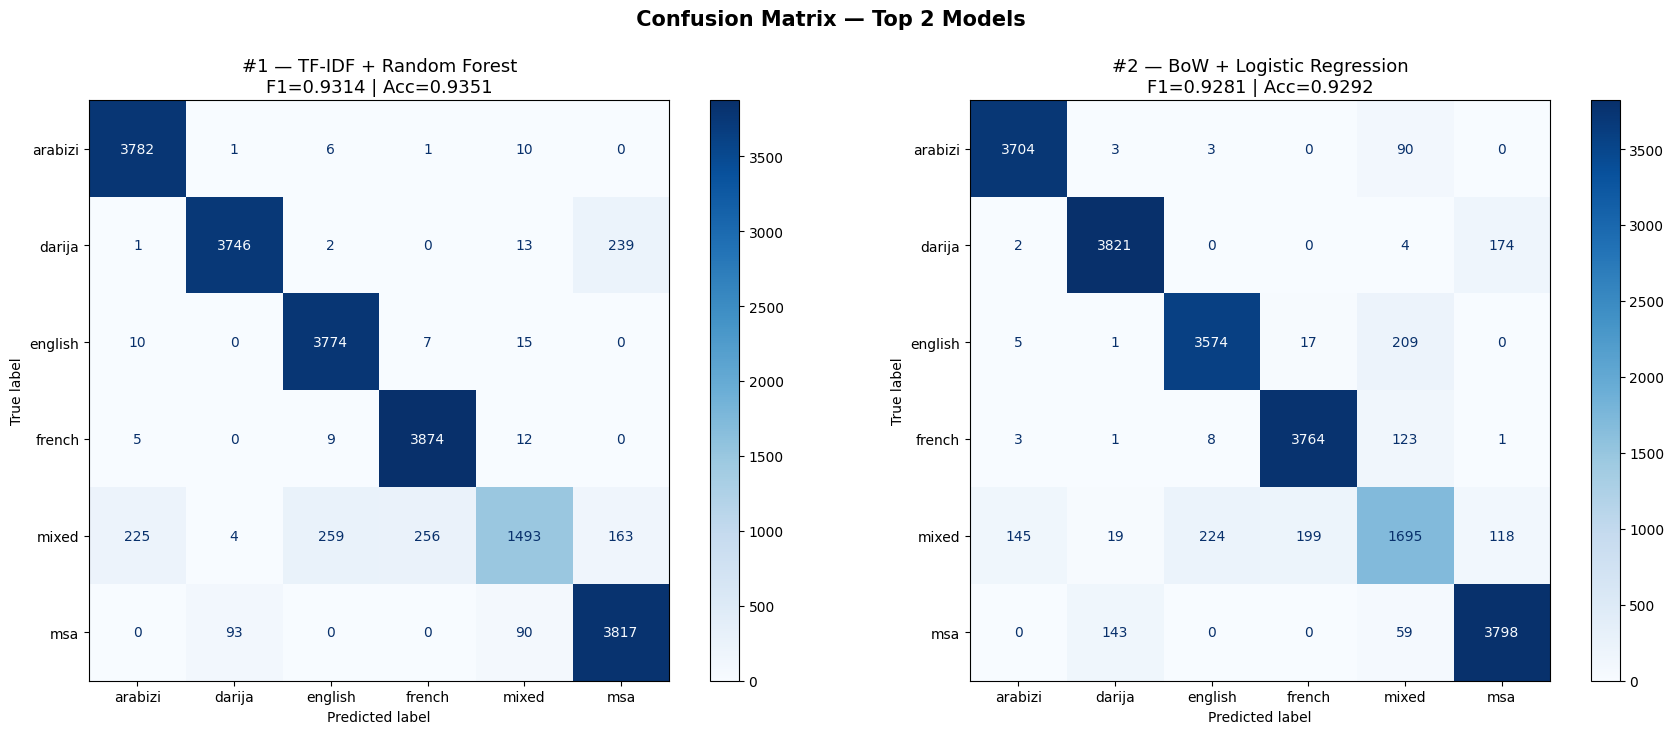

In [33]:
plot_top_confusion_matrices(results_df, trained_models, vectorized_data, y_test, top_n=2)

In [67]:
def build_ann(
    input_dim  : int,
    num_classes: int,
    dropout    : float = 0.4,
    lr         : float = 1e-3,
) -> keras.Model:

    inputs = keras.Input(shape=(input_dim,))

    # Bloc 1
    x = layers.Dense(512, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)

    # Bloc 2
    x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)

    # Bloc 3
    x = layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout / 2)(x)

    # Output
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=[
            keras.metrics.AUC(name='auc', multi_label=True),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
    )
    return model

In [68]:
input_dim  = vectorized_data['TF-IDF']['X_train'].shape[1]
num_classes = len(classes)

model = build_ann(input_dim, num_classes)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,728,965 (10.41 MB)

 Trainable params: 2,727,173 (10.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [74]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor  ='val_auc',
        patience = 6,
        mode     ='max',
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  ='val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
    ),
]

In [75]:
y_train_multilabel = np.stack(df_train_augmented['label'].values)
y_test_multilabel  = np.stack(df_test_augmented['label'].values)

In [76]:
history = model.fit(
    vectorized_data['TF-IDF']['X_train'].toarray(),
    y_train_multilabel,
    validation_data=(
        vectorized_data['TF-IDF']['X_test'].toarray(),
        y_test_multilabel,
    ),
    epochs    = 50,
    batch_size= 128,
    callbacks = callbacks,
)

W0000 00:00:1777992817.294688  138451 cpu_allocator_impl.cc:82] Allocation of 1800500000 exceeds 10% of free system memory.


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.9777 - loss: 0.2956 - precision: 0.9759 - recall: 0.9046 - val_auc: 0.9873 - val_loss: 0.2737 - val_precision: 0.9816 - val_recall: 0.9188 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9782 - loss: 0.2868 - precision: 0.9760 - recall: 0.9085 - val_auc: 0.9862 - val_loss: 0.2711 - val_precision: 0.9828 - val_recall: 0.9209 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9790 - loss: 0.2846 - precision: 0.9764 - recall: 0.9098 - val_auc: 0.9863 - val_loss: 0.2698 - val_precision: 0.9830 - val_recall: 0.9220 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9793 - loss: 0.2833 - precision: 0.9770 - recall: 0.9101 - val_auc: 0.9878 - val_loss: 0.2704 - val_precision: 0.9828 - val_recall: 0.9201 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9796 - loss: 0.2827 - precision: 0.9771 - r

In [77]:
THRESHOLD = 0.40
y_pred_proba  = model.predict(vectorized_data['TF-IDF']['X_test'])
y_pred_binary = (y_pred_proba >= THRESHOLD).astype(int)

print(classification_report(
    y_test_multilabel,
    y_pred_binary,
    target_names=classes,
    zero_division=0,
))

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

     arabizi       0.99      0.92      0.96      5000
      darija       0.96      0.96      0.96      4001
     english       0.99      0.95      0.97      5006
      french       0.99      0.95      0.97      5100
         msa       0.96      0.95      0.95      5200

   micro avg       0.98      0.94      0.96     24307
   macro avg       0.98      0.95      0.96     24307
weighted avg       0.98      0.94      0.96     24307
 samples avg       0.98      0.96      0.97     24307



In [78]:
def predict_code_switching_batch(sentences, vectorizer, trained_model, classes_list, threshold=30.0):
    cleaned_sentences = [text_cleanning(sentence) for sentence in sentences]
    batch_vec_dense = vectorizer.transform(cleaned_sentences).toarray().astype(np.float32)
    predictions = trained_model.predict(batch_vec_dense, verbose=0)
    
    for index, original_sentence in enumerate(sentences):
        print(f"Sentence {index + 1} : \"{original_sentence}\"")
        print("-" * 50)
        
        probs = predictions[index]
        
        for i, c in enumerate(classes_list):
            prob_pct = probs[i] * 100
            marker = "✅" if prob_pct > threshold else "🔸"
            print(f"{marker} {c:<15}: {prob_pct:>5.2f}%")
        print("\n")

comprehensive_tests = [
    "Le rapport financier sera présenté demain matin lors de la réunion.",
    
    "The backend infrastructure needs to be scalable and highly available.",
    
    "تعتبر تكنولوجيا الذكاء الاصطناعي من أهم الابتكارات في العصر الحديث.",
    
    "chokran bzaf 3la lmajhoudat dyalkom fl projet, tbarkellah 3likom.",
    
    "واش شفتي الماتش البارح؟ الدراري لعبو مزيان وربحو.",
    
    "Je dois terminer ce ticket daba wla le client ghadi it9ele9.",
    
    "C'est vraiment dommage, ما فهمتش علاش وقع هاد المشكل فجأة.",
    
    "Le ministère a annoncé aujourd'hui قرارات جديدة بخصوص التعليم العالي.",
    
    "Can you push the code to production 7it salina les tests kamlin.",
    
    "I will call you later, راني مشغول دابا فواحد الميتينغ.",
    
    "The new economic policy is implemented, وسيتم تقييم النتائج قريباً.",
    
    "Le nouveau design de l'application est vraiment très user-friendly et responsive.",
    
    "لقد تم إنجاز المهمة بنجاح، ودابا خاصنا غير نرتاحو شوية.",
    
    "يجب علينا مراجعة أمان النظام, hint fih chi bugs khasna nfixiwhom.",
    
    "kifach derti liha واش حماقيتي",
    
    "I think we should cancel le meeting dyal lyouma 7it I'm really tired.",
    
    "الرجاء إرسال الملفات عبر email باش نقدر نراجعهم دابا.",
    
    "Hello team, on se voit demain إن شاء الله bach nchoufo l'avancement dyal lkhedma."
]

predict_code_switching_batch(comprehensive_tests, vectorized_data['TF-IDF']["vectorizer"], model, classes)

Sentence 1 : "Le rapport financier sera présenté demain matin lors de la réunion."
--------------------------------------------------
🔸 arabizi        : 11.74%
🔸 darija         :  5.85%
🔸 english        :  5.56%
✅ french         : 93.33%
🔸 msa            :  6.63%


Sentence 2 : "The backend infrastructure needs to be scalable and highly available."
--------------------------------------------------
🔸 arabizi        :  7.17%
🔸 darija         :  5.11%
✅ english        : 95.28%
🔸 french         :  6.91%
🔸 msa            :  5.46%


Sentence 3 : "تعتبر تكنولوجيا الذكاء الاصطناعي من أهم الابتكارات في العصر الحديث."
--------------------------------------------------
🔸 arabizi        :  5.78%
🔸 darija         :  5.74%
🔸 english        :  5.37%
🔸 french         :  4.93%
✅ msa            : 94.43%


Sentence 4 : "chokran bzaf 3la lmajhoudat dyalkom fl projet, tbarkellah 3likom."
--------------------------------------------------
✅ arabizi        : 95.36%
🔸 darija         :  5.10%
🔸 english       

In [34]:
def save_dl_bundle(
    model          : keras.Model,
    vectorizer     ,
    classes        : list[str],
    save_path      : str,
    threshold      : float = 0.3,
) -> None:

    os.makedirs(save_path, exist_ok=True)

    model_path = f"{save_path}/model.keras"
    model.save(model_path)

    joblib.dump(vectorizer, f"{save_path}/vectorizer.pkl")

    meta = {
        "classes"     : classes,
        "num_classes" : len(classes),
        "threshold"   : threshold,
    }
    with open(f"{save_path}/meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

In [ ]:
save_dl_bundle(
    model      = model,
    vectorizer = vectorized_data['TF-IDF']["vectorizer"],
    classes    = classes,
    threshold  = 0.3,
    save_path  = "../models/language_identification_with_code_switching",
)

In [37]:
import pandas as pd
import requests
from io import BytesIO

def get_hf_parquet_urls(dataset, config=None):
    params = {"dataset": dataset}
    if config:
        params["config"] = config
    r = requests.get("https://datasets-server.huggingface.co/parquet", params=params)
    r.raise_for_status()
    return r.json()["parquet_files"]

def load_hf_parquet(dataset, config=None, split="train", n=None, columns=None):
    files = get_hf_parquet_urls(dataset, config)
    urls = [f["url"] for f in files if f["split"] == split]
    if not urls:
        raise ValueError(f"No files found for split={split}")
    r = requests.get(urls[0])
    r.raise_for_status()
    df = pd.read_parquet(BytesIO(r.content))
    if columns:
        df = df[[c for c in columns if c in df.columns]]
    if n:
        df = df.head(n)
    return df

print("Starting download...")
dataframes = []

# 1. Amazon Reviews (Allemand, Espagnol) - 2000 lignes
for lang in ["de", "es"]:
    df = load_hf_parquet(
        dataset="mteb/amazon_reviews_multi",
        config=lang,
        split="train",
        n=2000,
        columns=["text"]
    )
    df['lang'] = lang
    dataframes.append(df)
    print(f"  {lang.upper()} : {len(df)} rows loaded")

# 2. Papluca Language ID (Turc, NL, Italien, Portugais) - 2000 lignes
df_pap = load_hf_parquet(
    dataset="papluca/language-identification",
    split="train",
    columns=["labels", "text"]
)

for code in ['tr', 'nl', 'it', 'pt']:
    # Changement ici : .head(2000)
    df_lang = df_pap[df_pap['labels'] == code].head(2000)[['text']].copy()
    df_lang['lang'] = code
    dataframes.append(df_lang)
    print(f"  {code.upper()} : {len(df_lang)} rows loaded")

# 3. Wikipedia (Persan, Ourdou, Indonésien) - 2000 lignes
for lang_code, config in [("fa", "20231101.fa"), ("ur", "20231101.ur"), ("id", "20231101.id")]:
    df = load_hf_parquet(
        dataset="wikimedia/wikipedia",
        config=config,
        split="train",
        n=2000, # Changement ici : n=2000
        columns=["text"]
    )
    df['text'] = df['text'].str[:300]
    df['lang'] = lang_code
    dataframes.append(df)
    print(f"  {lang_code.upper()} : {len(df)} rows loaded")

print("Merging dataframes...")

df_noise = pd.concat(dataframes, ignore_index=True)

# Nettoyage
df_noise['text'] = df_noise['text'].str.replace('\n', ' ', regex=False).str.strip()
df_noise = df_noise[df_noise['text'].str.len() > 15].reset_index(drop=True)

# Application du Negative Sampling (Labels à 0 pour ton multilabel)
df_noise['label'] = [[0, 0, 0, 0, 0]] * len(df_noise)

df_noise = df_noise[['text', 'lang', 'label']]

df_noise.to_csv("../data/language_dictionaries/noise_negative_sampling.csv", index=False)

print(f"Done. {len(df_noise)} rows saved to noise_negative_sampling.csv")
print("\nRow count per language:")
print(df_noise['lang'].value_counts().to_string())
print("\nSample:")
print(df_noise.head(3).to_string())

Starting download...
  DE : 2000 rows loaded
  ES : 2000 rows loaded
  TR : 2000 rows loaded
  NL : 2000 rows loaded
  IT : 2000 rows loaded
  PT : 2000 rows loaded
  FA : 2000 rows loaded
  UR : 2000 rows loaded
  ID : 2000 rows loaded
Merging dataframes...
Done. 17930 rows saved to noise_negative_sampling.csv

Row count per language:
lang
de    2000
es    2000
fa    2000
it    1999
pt    1999
id    1999
nl    1995
ur    1986
tr    1952

Sample:
                                                                                                                                                                                                                                                                                                                                                                                                                text lang            label
0                                                                                                                         

In [23]:
import ast

df_noise = pd.read_csv("../data/language_dictionaries/noise_negative_sampling.csv")
df_noise['label'] = df_noise['label'].apply(ast.literal_eval)
df_noise.head()

,text,lang,label
0,Leider nach 1 Jahr kaputt Armband ist leider ...,de,"[0, 0, 0, 0, 0]"
1,EINS statt ZWEI Akkus!!! In der Lieferung war...,de,"[0, 0, 0, 0, 0]"
2,"Achtung Abzocke Ein Stern, weil gar keine geh...",de,"[0, 0, 0, 0, 0]"
3,"Zu viel des Guten Dachte, das wären einfach e...",de,"[0, 0, 0, 0, 0]"
4,Qualität sehr schlecht Meine Kinder haben kau...,de,"[0, 0, 0, 0, 0]"


In [24]:
X_train_raw, X_test_raw, y_train, y_test = split_data(
    df,
    text_col="text",
    target_col="lang",
    stratify="auto",
    verbose=True,
)

df_train = df.loc[X_train_raw.index].copy()
df_test  = df.loc[X_test_raw.index].copy()

texts_mix_train, labels_mix_train = generate_union_labeled_dataset(
    df_train,
    n_samples=20_000,
    random_state=42,
)
texts_mix_test, labels_mix_test = generate_union_labeled_dataset(
    df_test,
    n_samples=4_000,
    random_state=99,
)

df_mixed_train = pd.DataFrame({
    'text' : texts_mix_train,
    'lang' : 'mixed',
    'label': labels_mix_train,
})
df_mixed_test = pd.DataFrame({
    'text' : texts_mix_test,
    'lang' : 'mixed',
    'label': labels_mix_test,
})

# Split noise 80/20
df_noise_train = df_noise.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_noise_test  = df_noise.drop(df_noise_train.index).reset_index(drop=True)

# Concatenation finale : data originale + mixed + noise
df_train_augmented = (
    pd.concat([df_train, df_mixed_train, df_noise_train], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
df_test_augmented = (
    pd.concat([df_test, df_mixed_test, df_noise_test], ignore_index=True)
    .sample(frac=1, random_state=99)
    .reset_index(drop=True)
)

print("Train distribution after augmentation:")
print(df_train_augmented['lang'].value_counts())
print("\nTest distribution after augmentation:")
print(df_test_augmented['lang'].value_counts())

X_train = df_train_augmented['text']
X_test  = df_test_augmented['text']
y_train = df_train_augmented['label']
y_test  = df_test_augmented['label']

Train : 78,119 samples
Test  : 19,530 samples
Train distribution after augmentation:
lang
msa        16006
darija     16006
french     15614
english    15291
arabizi    15202
mixed      12000
es          1623
it          1609
de          1605
fa          1603
ur          1586
nl          1583
tr          1580
pt          1578
id          1577
Name: count, dtype: int64

Test distribution after augmentation:
lang
msa        4001
darija     4001
french     3904
english    3823
arabizi    3801
mixed      2400
id         1999
ur         1587
Name: count, dtype: int64


In [25]:
vectorized_data = precompute_vectorizations(
    vectorizers,
    X_train,
    X_test,
)

Fitting BoW...
  → shape : (104463, 5000)
Fitting TF-IDF...
  → shape : (104463, 5000)


In [26]:
def build_ann(
    input_dim  : int,
    num_classes: int,
    dropout    : float = 0.35,
    lr         : float = 1e-3,
) -> keras.Model:

    inputs = keras.Input(shape=(input_dim,))

    # Bloc 1
    x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)

    # Bloc 2
    x = layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)

    # Bloc 3
    x = layers.Dense(64, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout / 2)(x)

    # Output
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.02),  # reduit
        metrics=[
            keras.metrics.AUC(name='auc', multi_label=True),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
    )
    return model

In [27]:
input_dim  = vectorized_data['TF-IDF']['X_train'].shape[1]
num_classes = len(classes)

model = build_ann(input_dim, num_classes)
model.summary()

I0000 00:00:1778012559.878697  478640 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4149 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,525 (5.05 MB)

 Trainable params: 1,322,629 (5.05 MB)

 Non-trainable params: 896 (3.50 KB)

In [28]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor  ='val_auc',
        patience = 6,
        mode     ='max',
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  ='val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
    ),
]

In [29]:
y_train_multilabel = np.stack(df_train_augmented['label'].values)
y_test_multilabel  = np.stack(df_test_augmented['label'].values)

In [30]:
history = model.fit(
    vectorized_data['TF-IDF']['X_train'].toarray(),
    y_train_multilabel,
    validation_data=(
        vectorized_data['TF-IDF']['X_test'].toarray(),
        y_test_multilabel,
    ),
    epochs    = 50,
    batch_size= 128,
    callbacks = callbacks,
)

W0000 00:00:1778012586.535077  478640 cpu_allocator_impl.cc:82] Allocation of 2089260000 exceeds 10% of free system memory.
W0000 00:00:1778012592.841312  478640 cpu_allocator_impl.cc:82] Allocation of 2089260000 exceeds 10% of free system memory.


Epoch 1/50


I0000 00:00:1778012597.029444  484079 service.cc:153] XLA service 0x7cc41003ae30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778012597.029460  484079 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778012597.126720  484079 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778012597.532225  484079 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1778012597.632750  484079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4109__.44
I0000 00:00:1778012598.174112  484079 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 54/817 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8719 - loss: 0.5255 - precision: 0.5365 - recall: 0.7886

I0000 00:00:1778012604.829184  484079 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


807/817 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9571 - loss: 0.2698 - precision: 0.8879 - recall: 0.8592

I0000 00:00:1778012607.531580  484080 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4109__.44


817/817 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9573 - loss: 0.2690 - precision: 0.8887 - recall: 0.8595

W0000 00:00:1778012612.427425  478640 cpu_allocator_impl.cc:82] Allocation of 510320000 exceeds 10% of free system memory.
W0000 00:00:1778012612.917283  478640 cpu_allocator_impl.cc:82] Allocation of 510320000 exceeds 10% of free system memory.
I0000 00:00:1778012613.690448  484081 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778012615.631500  484080 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778012616.750095  484080 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good re

817/817 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - auc: 0.9724 - loss: 0.2080 - precision: 0.9527 - recall: 0.8794 - val_auc: 0.9900 - val_loss: 0.1472 - val_precision: 0.9834 - val_recall: 0.9152 - learning_rate: 0.0010
Epoch 2/50
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9822 - loss: 0.1610 - precision: 0.9741 - recall: 0.9059 - val_auc: 0.9907 - val_loss: 0.1377 - val_precision: 0.9842 - val_recall: 0.9234 - learning_rate: 0.0010
Epoch 3/50
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9834 - loss: 0.1555 - precision: 0.9748 - recall: 0.9112 - val_auc: 0.9908 - val_loss: 0.1366 - val_precision: 0.9852 - val_recall: 0.9237 - learning_rate: 0.0010
Epoch 4/50
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9841 - loss: 0.1535 - precision: 0.9755 - recall: 0.9130 - val_auc: 0.9906 - val_loss: 0.1373 - val_precision: 0.9832 - val_recall: 0.9260 - learning_rate: 0.0010
Epoch 5/50
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9840 - loss: 0.1543 - precision: 0.9747 - recall: 0.

In [31]:
THRESHOLD = 0.40
y_pred_proba  = model.predict(vectorized_data['TF-IDF']['X_test'])
y_pred_binary = (y_pred_proba >= THRESHOLD).astype(int)

print(classification_report(
    y_test_multilabel,
    y_pred_binary,
    target_names=classes,
    zero_division=0,
))

798/798 ━━━━━━━━━━━━━━━━━━━━ 237s 296ms/step
              precision    recall  f1-score   support

     arabizi       0.99      0.93      0.96      5001
      darija       0.97      0.96      0.96      4001
     english       0.99      0.96      0.97      5023
      french       0.99      0.95      0.97      5104
         msa       0.96      0.95      0.96      5201

   micro avg       0.98      0.95      0.96     24330
   macro avg       0.98      0.95      0.96     24330
weighted avg       0.98      0.95      0.96     24330
 samples avg       0.85      0.83      0.83     24330



In [32]:
def predict_batch(sentences, vectorizer, trained_model, classes_list, threshold=30.0):
    cleaned_sentences = [text_cleanning(sentence) for sentence in sentences]
    batch_vec_dense = vectorizer.transform(cleaned_sentences).toarray().astype(np.float32)
    predictions = trained_model.predict(batch_vec_dense, verbose=0)
    
    for index, original_sentence in enumerate(sentences):
        print(f"Sentence {index + 1} : \"{original_sentence}\"")
        print("-" * 50)
        
        probs = predictions[index]
        
        for i, c in enumerate(classes_list):
            prob_pct = probs[i] * 100
            marker = "✅" if prob_pct > threshold else "🔸"
            print(f"{marker} {c:<15}: {prob_pct:>5.2f}%")
        print("\n")

comprehensive_tests = [
    # --- Données originales ---
    "Le rapport financier sera présenté demain matin lors de la réunion.",
    "The backend infrastructure needs to be scalable and highly available.",
    "تعتبر تكنولوجيا الذكاء الاصطناعي من أهم الابتكارات في العصر الحديث.",
    "chokran bzaf 3la lmajhoudat dyalkom fl projet, tbarkellah 3likom.",
    "واش شفتي الماتش البارح؟ الدراري لعبو مزيان وربحو.",
    "Je dois terminer ce ticket daba wla le client ghadi it9ele9.",
    "C'est vraiment dommage, ما فهمتش علاش وقع هاد المشكل فجأة.",
    "Le ministère a annoncé aujourd'hui قرارات جديدة بخصوص التعليم العالي.",
    "Can you push the code to production 7it salina les tests kamlin.",
    "I will call you later, راني مشغول دابا فواحد الميتينغ.",
    "The new economic policy is implemented, وسيتم تقييم النتائج قريباً.",
    "Le nouveau design de l'application est vraiment très user-friendly et responsive.",
    "لقد تم إنجاز المهمة بنجاح، ودابا خاصنا غير نرتاحو شوية.",
    "يجب علينا مراجعة أمان النظام, hint fih chi bugs khasna nfixiwhom.",
    "kifach derti liha واش حماقيتي",
    "I think we should cancel le meeting dyal lyouma 7it I'm really tired.",
    "الرجاء إرسال الملفات عبر email باش نقدر نراجعهم دابا.",
    "Hello team, on se voit demain إن شاء الله bach nchoufo l'avancement dyal lkhedma.",
    
    # --- Nouveaux exemples Out-of-Distribution (OOD) ---
    "Dieses Restaurant hält sich für ein Michelin-Restaurant, ohne jedoch dem Standard zu entsprechen.",
    "Unangenehme, Katastrophe, ein bisschen trocken ( Hähnchen 🐔), sehr sehr sehr Teuer...",
    "Buena comida y buen servio",
    "El local es súper chulo, moderno y limpio , con mucho rollo vanguardista...",
    "Eine Reise wert! Das Restaurant alleine ist schon eine Reise nach Casablanca wert...",
    "Suasana malam yang luar biasa saat anda berkunjung ke sini.. Makanan Khus-Khus yang luar biasa jumbo...",
    "L'hamburger migliore di ",
    "Fas kahvaltısı yedik çok lezzetliydi. Garsonlar yeterince ilgili değil ve ödeme yaparken...",
    "Porsiyonları gayet küçük ve gereksiz pahalı..Sadece abartılmış bir restoran...",
    "Sehr schönes Café toller Innenhof nette Bedienung ein Muss wenn man nach Casablanca kommt",
    "Se siete turisti non venite qui , il cameriere con l’apparecchio hai denti pensando che non sapessi la lingua...",
    "Dobra hrana, projazno osebje",
    "Burada kahvaltı lezzetli sunum çok iyi siyah demli bir çay olmaması kötü benim için...",
    "Variedad y calidad.",
    "Der service war top die vorspeisen platta und käfte auch megalecker. steak war katastrophal...",
    "Deliciosa comida típica de Marruecos. El servicio muy bueno. Las sillas algo incómodas...",
    "Tolle Location und gutes lokales Essen. Der Kellner gibt Empfehlungen zu den Mahlzeiten...",
    "Heerlijk plekje voor een lunch (en in de zomer ongetwijfeld ook diner) Helaas voelde het tegelijkertijd ook als een tourist trap...",
    "Kazablanka’daki meşhur restoran/kafelerden birisi. Bu nedenle çok kalabalık ve biraz sıra beklemeniz gerekiyor...",
    "Türk arkadaşlarım buraya gelmeyin. Salatası yıkanmamıştı ve ilk gün geldiğimizde buraya kahvaltıya gelme gibi bir gaflette bulunduk..."
]

predict_batch(comprehensive_tests, vectorized_data['TF-IDF']["vectorizer"], model, classes)

Sentence 1 : "Le rapport financier sera présenté demain matin lors de la réunion."
--------------------------------------------------
🔸 arabizi        :  2.58%
🔸 darija         :  1.44%
🔸 english        :  1.12%
✅ french         : 93.20%
🔸 msa            :  0.79%


Sentence 2 : "The backend infrastructure needs to be scalable and highly available."
--------------------------------------------------
🔸 arabizi        :  1.90%
🔸 darija         :  2.41%
✅ english        : 97.73%
🔸 french         :  4.22%
🔸 msa            :  2.08%


Sentence 3 : "تعتبر تكنولوجيا الذكاء الاصطناعي من أهم الابتكارات في العصر الحديث."
--------------------------------------------------
🔸 arabizi        :  1.17%
🔸 darija         :  1.20%
🔸 english        :  0.99%
🔸 french         :  0.90%
✅ msa            : 98.85%


Sentence 4 : "chokran bzaf 3la lmajhoudat dyalkom fl projet, tbarkellah 3likom."
--------------------------------------------------
✅ arabizi        : 99.47%
🔸 darija         :  0.68%
🔸 english       

In [35]:
save_dl_bundle(
    model      = model,
    vectorizer = vectorized_data['TF-IDF']["vectorizer"],
    classes    = classes,
    threshold  = 0.3,
    save_path  = "../models/language_identification_with_code_switching_and_noise",
)